# 1. Install Dependencies and Setup

In [ ]:
from pathlib import Path
import sys
from tqdm import tqdm
sys.path.append(str(Path.cwd().parent))
from project_1.data.load_preprocces import load_data
from project_1.features.feature_extraction import (
    feature_extraction_mel,
    feature_extraction_mfcc,
    file_opener,
    normalize_data
)

# 2. visualising the data

In [2]:
data_dir = Path.cwd().parent / "data"

data = load_data(data_dir)

features_func = {
    "mfcc": feature_extraction_mfcc, 
    "mel": feature_extraction_mel}



In [ ]:
features_holder = {"mfcc": {"X": [], "y": []}, "mel": {"X": [], "y":[]}}


for class_label, file_paths in tqdm(data.items()):
    for file_path in file_paths:
        features = file_opener(file_path, features_func)
        for name, value in features.items():
            features_holder[name]["X"].append(value)
            features_holder[name]["y"].append(class_label)


  0%|          | 0/8 [00:00<?, ?it/s]c:\Users\jkid4\.virtualenvs\project_1_folder-MwoIS0fJ\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 8/8 [05:04<00:00, 38.05s/it]


# 3. barplot creation

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
color_type = sns.color_palette("husl", 8)


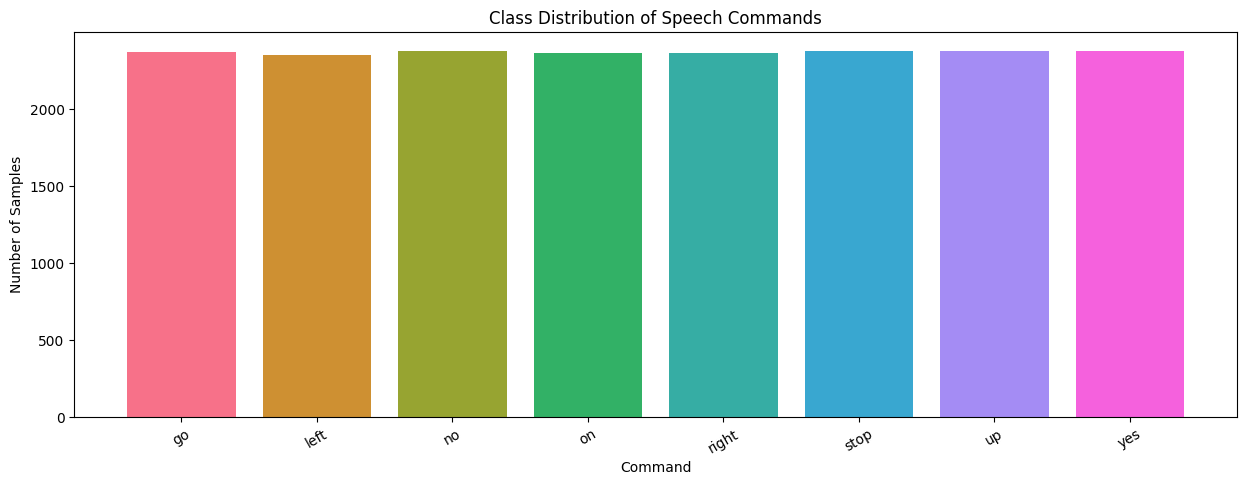

In [78]:
counts = [mel_labels.count(label) for label in labels_names]

# plot
plt.figure(figsize=(15, 5))
bars = plt.bar(labels_names, counts, color=color_type)

plt.title("Class Distribution of Speech Commands")
plt.xlabel("Command")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)

plt.show()

# 4. dimentionality reduction plot


In [56]:
from sklearn.decomposition import PCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd


mel_data = features_holder["mel"]["X"]
mfcc_data = features_holder["mfcc"]["X"]

mel_labels = features_holder["mel"]["y"]

In [57]:
labels_names = ["go", "left", "no", "on", "right", "stop", "up", "yes"]
label_to_idx = {name: i for i, name in enumerate(labels_names)}
numeric_mel_labels = [label_to_idx[label] for label in mel_labels]

In [58]:
mel_data = np.array([np.mean(x.T, axis=0) for x in mel_data])
mfcc_data = np.array([np.mean(x.T, axis=0) for x in mfcc_data])


In [91]:
mel_data = normalize_data(mel_data , "mel")
mfcc_data = normalize_data(mfcc_data, "mfcc")

In [ ]:
pca = PCA(n_components=3,
          svd_solver="full",
          random_state=42)
reduced_data_pca = pca.fit_transform(mfcc_data)
# Plotting the reduced data
df = pd.DataFrame(reduced_data_pca, columns=["x", "y", "z"])
df["label"] = numeric_mel_labels
df["color"] = [color_type[i] for i in numeric_mel_labels]

fig = px.scatter_3d(
    df, x="x", y="y", z="z", color="color", title="PCA: 3D Representation of Data"
)
fig.update_layout(showlegend=False)
fig.show()


In [107]:
tsne = TSNE(
    n_components=3, 
    perplexity=30, 
    learning_rate=2000, 
    random_state=42
)
reduced_data_tsne = tsne.fit_transform(mel_data)

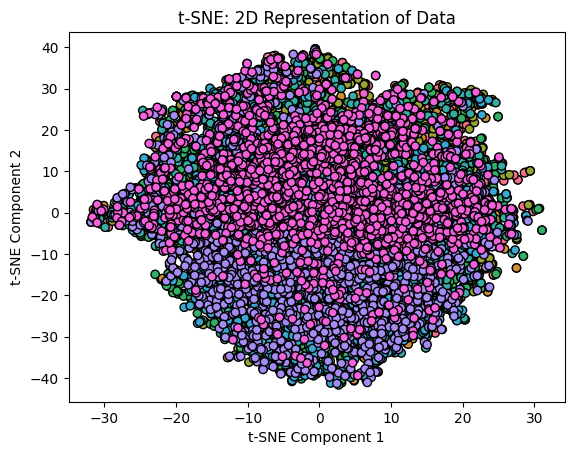

In [108]:
plt.scatter(
    reduced_data_tsne[:, 0],
    reduced_data_tsne[:, 1],
    c=[color_type[i] for i in numeric_mel_labels],
    edgecolors="k",
)
plt.title("t-SNE: 2D Representation of Data")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    reduced_data_tsne[:, 0],
    reduced_data_tsne[:, 1],
    reduced_data_tsne[:, 2],
    c=[color_type[i] for i in numeric_mel_labels],
    edgecolors="k",
)



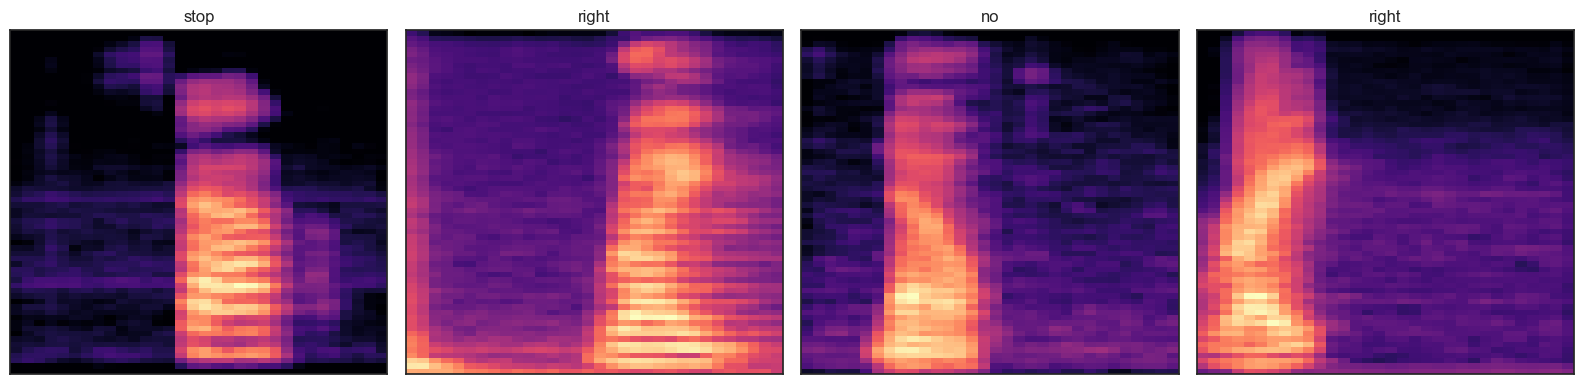

In [117]:
import random
import librosa
sns.set_theme(style="white")

# collect all files into one pool
all_files = []
for label in labels_names:
    all_files.extend(data[label])

# pick 4 random samples
sample_files = random.sample(all_files, 4)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, file_path in enumerate(sample_files):
    y, sr = librosa.load(file_path, sr=16000)

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    ax = axes[i]
    librosa.display.specshow(mel_db, sr=sr, ax=ax, cmap="magma")

    # optional: show class label in title
    label = file_path.parent.name if hasattr(file_path, "parent") else ""
    ax.set_title(label)

    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()
